In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from google.colab import drive
drive.mount('/content/drive')

csv_file_path = '/content/drive/MyDrive/data-selected-columns.csv'  # Caminho do arquivo na pasta do Drive
df = pd.read_csv(csv_file_path) # Lê o dataset
display(df.head()) #Exibe as 5 primeiras linhas da tabela
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. COLETA E CARGA DE DADOS
# Lendo o arquivo CSV anexado
df = pd.read_csv(csv_file_path)

print("--- Visão Inicial dos Dados ---")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,198.0000,0.10430


--- Visão Inicial dos Dados ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  
0          0.11840           0.27760          0.3001              0.14710  
1          0.08474           0.07864          0.0869              0.07017  
2          0.10960           0.15990          0.1974              0.12790  
3          0.14250           0.28390          0.2414              0.10520  
4          0.10030           0.13280        198.0000              0.10430  


In [5]:

# 2. PRÉ-PROCESSAMENTO DE DADOS (A parte mais crítica)

'''Limpeza de Outliers Ocultos
Ao analisar o dataset, nota-se que colunas de proporção (que deveriam ir de 0 a 1)
contêm valores errôneos aberrantes (ex: 166, 198, 79). Se deixarmos esses valores,
eles distorcerão completamente os pesos da Regressão Logística.'''
cols_proporcao = [
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
]

for col in cols_proporcao:
    # 'errors="coerce"' força qualquer texto ou inconsistência a virar NaN (Not a Number)
    df[col] = pd.to_numeric(df[col], errors="coerce")
    # Substituímos valores logicamente impossíveis para proporções (> 1.0) por NaN
    df.loc[df[col] > 1.0, col] = np.nan

'''Elementos Faltantes (Imputação)
Em vez de simplesmente deletar as linhas com problemas (o que reduziria nossa base),
calculamos a mediana de cada coluna numérica e preenchemos as lacunas (NaNs).
Usamos a mediana porque ela é "robusta" e não é afetada por valores extremos.'''
df = df.fillna(df.median(numeric_only=True))

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separando as variáveis preditoras (X) do alvo que queremos prever (y)
# Removemos 'id' (não tem poder preditivo) e 'diagnosis' (que é o próprio y)
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

''' Divisão Estratificada (Train/Test Split)
O parâmetro 'stratify=y' garante que a proporção de casos de câncer Maligno e Benigno
seja exatamente a mesma tanto no conjunto de treino quanto no de teste, evitando que
o modelo treine com uma classe e seja testado sem ela.'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

''' Normalização / Escalonamento (StandardScaler)
# A Regressão Logística calcula coeficientes baseados na magnitude das variáveis.
# A coluna 'area_mean' tem valores na casa dos milhares (ex: 1001.0), enquanto 'smoothness_mean'
# está na casa dos decimais (ex: 0.1184). Se não normalizarmos, o modelo achará que a área é
# milhares de vezes mais importante simplesmente porque o número é maior.
# O StandardScaler transforma todas as colunas para a mesma escala (Média = 0, Desvio Padrão = 1).
scaler = StandardScaler()
# O 'fit_transform' aprende a média/desvio do treino e aplica.'''
X_train_scaled = scaler.fit_transform(X_train)
# No teste, apenas aplicamos a transformação matemática aprendida no treino (NUNCA fazemos fit no teste).
X_test_scaled = scaler.transform(X_test)

In [6]:

# 3. MODELAGEM E TREINO

# Criamos o estimador de Regressão Logística e o treinamos com os dados escalonados
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [7]:


# 4. AVALIAÇÃO DO MODELO

# O modelo tenta adivinhar o diagnóstico para os dados de teste que ele nunca viu antes
y_pred = model.predict(X_test_scaled)

# Calculando as métricas solicitadas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========================================")
print("          MÉTRICAS DE DESEMPENHO        ")
print("========================================")
print(f"Acurácia (Total de acertos):          {acc:.4f}")
print(f"Precisão (Dos previstos como M, quantos eram): {prec:.4f}")
print(f"Recall (Dos M reais, quantos achamos):       {rec:.4f}")
print(f"F1-Score (Balanço entre os dois):     {f1:.4f}")
print("\nRelatório Estatístico de Classificação:")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))


          MÉTRICAS DE DESEMPENHO        
Acurácia (Total de acertos):          0.9125
Precisão (Dos previstos como M, quantos eram): 0.8684
Recall (Dos M reais, quantos achamos):       0.9429
F1-Score (Balanço entre os dois):     0.9041

Relatório Estatístico de Classificação:
              precision    recall  f1-score   support

     Benigno       0.95      0.89      0.92        45
     Maligno       0.87      0.94      0.90        35

    accuracy                           0.91        80
   macro avg       0.91      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



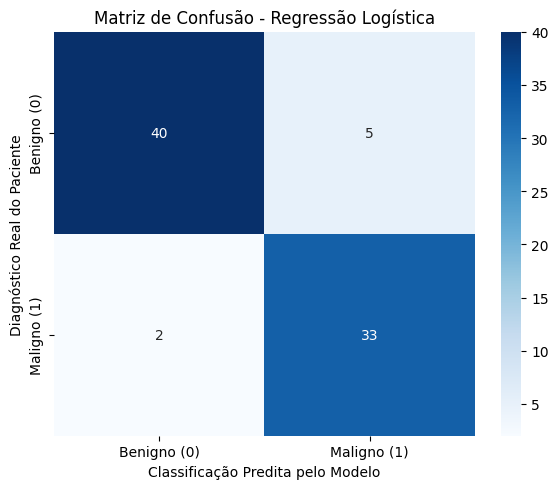

In [8]:

# 5. VISUALIZAÇÃO (Matriz de Confusão)

# Gera uma matriz cruzando o que era Real vs o que o modelo Predisse
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno (0)", "Maligno (1)"],
    yticklabels=["Benigno (0)", "Maligno (1)"],
)
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Classificação Predita pelo Modelo")
plt.ylabel("Diagnóstico Real do Paciente")
plt.tight_layout()
plt.show()